## **Business Questions**

### 📌 **1. Can we predict whether a fine will be paid through the *Traffic Fines* app?**  

---

### 📌 **2. What factors influence a user’s decision to pay the fine via the app?**  

---

### 📌 **3. How can we process real large-scale user log data?**  

---

### 📌 **4. How can we deploy the model into the app to make daily predictions efficiently?**  

---


In [1]:
!pip install matplotlib -q

In [2]:
import pyspark
import matplotlib.pyplot as plt
import os
from pyspark import SparkContext, SparkConf
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import pandas as pd
pd.set_option("display.max_columns", None)
import re
from datetime import datetime

In [3]:
dir_path = '/home/jovyan/__AP25RAY/data/events'

In [4]:
items = os.listdir(dir_path)

In [5]:
counter = 0
total_size = 0
for file in items:
    if file.endswith('.csv'):
        counter += 1
        item_path = os.path.join(dir_path, file)
        item_size = os.path.getsize(item_path)
        total_size += item_size
print(f'There are {counter} files to analyze')
print(f'The size of the files to analze is {round(total_size / (1000 ** 3),2)} GB')

There are 365 files to analyze
The size of the files to analze is 220.16 GB


In [6]:
beg_file = items[1]
last_file = items[-1]
beg_file  = re.search(r"\d{4}-\d{2}-\d{2}", beg_file).group()
last_file  = re.search(r"\d{4}-\d{2}-\d{2}", last_file).group()
beg_date = datetime.strptime(beg_file, "%Y-%m-%d")
last_date = datetime.strptime(last_file, "%Y-%m-%d")
delta = last_date - beg_date
print(f"We have {delta.days} days to analyze")

We have 364 days to analyze


### Spark initialization

In [7]:
def uiWebUrl(self):
    from urllib.parse import urlparse
    web_url = self._jsc.sc().uiWebUrl().get()
    port = urlparse(web_url).port
    return '{}proxy/{}/jobs/'.format(os.environ['JUPYTERHUB_SERVICE_PREFIX'], port)

SparkContext.uiWebUrl = property(uiWebUrl)



# Spark settings
conf = SparkConf()
conf.set('spark.master', 'local[*]')    # max 5 cores available, use `local[*]` for all cores
conf.set('spark.driver.memory', '16G')  # max 16 GB available
conf.set('spark.driver.maxResultSize', '4G')

conf.set('spark.sql.adaptive.logLevel', 'INFO')  # Логирование адаптивных запросов
conf.set('spark.sql.execution.arrow.maxRecordsPerBatch', '10000')

sc = SparkContext(conf=conf)

sc.setLogLevel("INFO")

spark = SparkSession(sc)
spark

## Let's load one of 300 datasets and take a look at it

In [8]:
file_path = os.path.join(dir_path, items[1])
sdf = spark.read.option('header', 'true').csv(file_path)

In [9]:
sdf.show()

+-------------------+--------------------+--------------------+----------------------+-----------------------+---------------+-----------+--------------------+--------------------+----+---------------+----------------+--------------------+-------------+-------------------+-----------------+-----------+--------------------+--------------------+--------------------+---+---+-------------+---------------------+-------+----------+--------------------+-----------+----------------+--------------------+----------------+--------------+
|     event_datetime|          event_json|          event_name|event_receive_datetime|event_receive_timestamp|event_timestamp| session_id|     installation_id|appmetrica_device_id|city|connection_type|country_iso_code|         device_ipv6|device_locale|device_manufacturer|     device_model|device_type|          google_aid|             ios_ifa|             ios_ifv|mcc|mnc|operator_name|original_device_model|os_name|os_version|          profile_id|windows_aid|app_b

In [10]:
print(f'There are {sdf.count()} rows and {len(sdf.columns)} columns in the dataset') 

There are 705512 rows and 32 columns in the dataset


In [11]:
sdf.printSchema()

root
 |-- event_datetime: string (nullable = true)
 |-- event_json: string (nullable = true)
 |-- event_name: string (nullable = true)
 |-- event_receive_datetime: string (nullable = true)
 |-- event_receive_timestamp: string (nullable = true)
 |-- event_timestamp: string (nullable = true)
 |-- session_id: string (nullable = true)
 |-- installation_id: string (nullable = true)
 |-- appmetrica_device_id: string (nullable = true)
 |-- city: string (nullable = true)
 |-- connection_type: string (nullable = true)
 |-- country_iso_code: string (nullable = true)
 |-- device_ipv6: string (nullable = true)
 |-- device_locale: string (nullable = true)
 |-- device_manufacturer: string (nullable = true)
 |-- device_model: string (nullable = true)
 |-- device_type: string (nullable = true)
 |-- google_aid: string (nullable = true)
 |-- ios_ifa: string (nullable = true)
 |-- ios_ifv: string (nullable = true)
 |-- mcc: string (nullable = true)
 |-- mnc: string (nullable = true)
 |-- operator_name: s

In [14]:
# Let's take a chunk of the dataset and get acquinted with the data
df_test = sdf.limit(100000).toPandas()

In [15]:
df_test.head()

,event_datetime,event_json,event_name,event_receive_datetime,event_receive_timestamp,event_timestamp,session_id,installation_id,appmetrica_device_id,city,connection_type,country_iso_code,device_ipv6,device_locale,device_manufacturer,device_model,device_type,google_aid,ios_ifa,ios_ifv,mcc,mnc,operator_name,original_device_model,os_name,os_version,profile_id,windows_aid,app_build_number,app_package_name,app_version_name,application_id
0,2024-01-01 19:10:08,"""{""""From"""":""""тип 101""""}""",Push/Локальный пуш,2024-01-01 18:10:09,1704121809,1704121808,10000000026,c471f341557e4f299daa4a31038b14ce,883092048383528367,None,cell,RU,2a00:1fa1:c630:3422:416c:1d1d:e309:adf2,ru_RU,Apple,iPhone 13,phone,None,None,D9B660BF-2166-428B-87D6-13ABEF6DC2D4,0,0,None,"iPhone14,5",ios,17.2.1,7ad33fd586b2c4df895846dded13e053,None,770,ru.reactivephone.shtrafy,4.15,108955
1,2024-01-01 22:57:10,"""{""""From"""":""""тип 103""""}""",Push/Локальный пуш,2024-01-01 21:57:11,1704135431,1704135430,10000000054,6df0b38e27884da781dbdeb8cf20b963,2148785056861469527,None,cell,RU,::ffff:46.31.24.93,ru_RU,Apple,iPhone 11 Pro Max,phone,None,None,6B22BC14-1AE0-43BF-8091-555B118C8EC6,0,0,None,"iPhone12,5",ios,16.6.1,8beb16376d555c156d3ee6c60d756b6b,None,770,ru.reactivephone.shtrafy,4.15,108955
2,2024-01-01 13:17:02,"""{""""From"""":""""тип 101""""}""",Push/Локальный пуш,2024-01-01 12:17:03,1704100623,1704100622,10000000152,ca6631d7ae9bded7b653221411a7950f,3248842197909942617,None,cell,RU,::ffff:91.108.29.77,ru_RU,Apple,iPhone 6s Plus,phone,None,942DA9D5-319C-41E0-B032-37573F553C0D,87B4B4D9-F6E1-4E71-A66D-D8487C64D86E,0,0,None,"iPhone8,2",ios,15.8,d0d257e0302fa767673aac84102a6989,None,770,ru.reactivephone.shtrafy,4.15,108955
3,2024-01-01 18:19:29,"""{""""From"""":""""тип 101""""}""",Push/Локальный пуш,2024-01-01 17:19:29,1704118769,1704118769,10000000395,44b2667d000647ed9e8aabf94f08b0f0,6303866386173724721,None,cell,RU,::ffff:176.59.55.52,ru_RU,Apple,iPhone X,phone,None,6A22626E-92E5-4F68-815A-20C8DA5F29A5,0DB27FFC-403B-4B54-8F1F-6BC50017B7CA,0,0,None,"iPhone10,6",ios,16.7.2,9e5b60a9eba72e3c7ace01206ea294a1,None,770,ru.reactivephone.shtrafy,4.15,108955
4,2024-01-01 10:35:37,"""{""""From"""":""""тип 101""""}""",Push/Локальный пуш,2024-01-01 09:35:38,1704090938,1704090937,10000000002,297f035276474283ae58223744d6b9e3,13343753368446759882,None,cell,RU,::ffff:188.113.137.37,ru_RU,Apple,"iPhone16,2",phone,None,352C6ED5-0DCD-42AA-82C7-9675C2837CC0,FE1E8B5D-8014-430C-8531-C13CA174CFFC,0,0,None,"iPhone16,2",ios,17.1.2,8480927fe321700dba3f1fd2550103e6,None,770,ru.reactivephone.shtrafy,4.15,108955


**Составим предположение о том, что могут значит признаки:**
- event_json: это внутренний код типа пуша
- event_datetime: когда событие произошло на устройстве
- event_receive_datetime: когда AppMetrica его получила
- session_id: сессия пользователя
- installation_id: уникальный ID установки приложения
- appmetrica_device_id: идентификатор устройства для аналитики
- city:  город
- connection_type: тип сети, с которой пользователь зашел
- country_iso_code: код страны установки
- device_manufacturer: производитель устройства
- device_model: модель устройства
- ios_ifa (Identifier For Advertisers): рекламный идентификатор iOS
- ios_ifv (Identifier For Vendor): уникальный ID устройства для конкретного разработчика (Vendor)
- device_locale: локаль пользователя
- device_type: тип устройства
- google_aid: Android Advertising ID
- mcc: mobile country code
- mnc: оператор
- operator_name: название оператора
- app_package_name: название приложения
- app_version_name: версия приложения
- app_build_number: еще какая-то информация о приложении
- application_id: внутренний ID AppMetrica

In [16]:
print(f'There are {df_test["event_json"].nunique()} unique event codes in the chunk')

There are 3085 unique event codes in the chunk


In [17]:
print(f'There are {df_test["session_id"].nunique()} unique sessions in the chunk')

There are 7276 unique sessions in the chunk


In [18]:
print(f'There are {df_test["installation_id"].nunique()} unique installation ids in the chunk')

There are 20282 unique installation ids in the chunk


In [19]:
print(f'There are {df_test["profile_id"].nunique()} unique profile ids in the chunk')

There are 11455 unique profile ids in the chunk


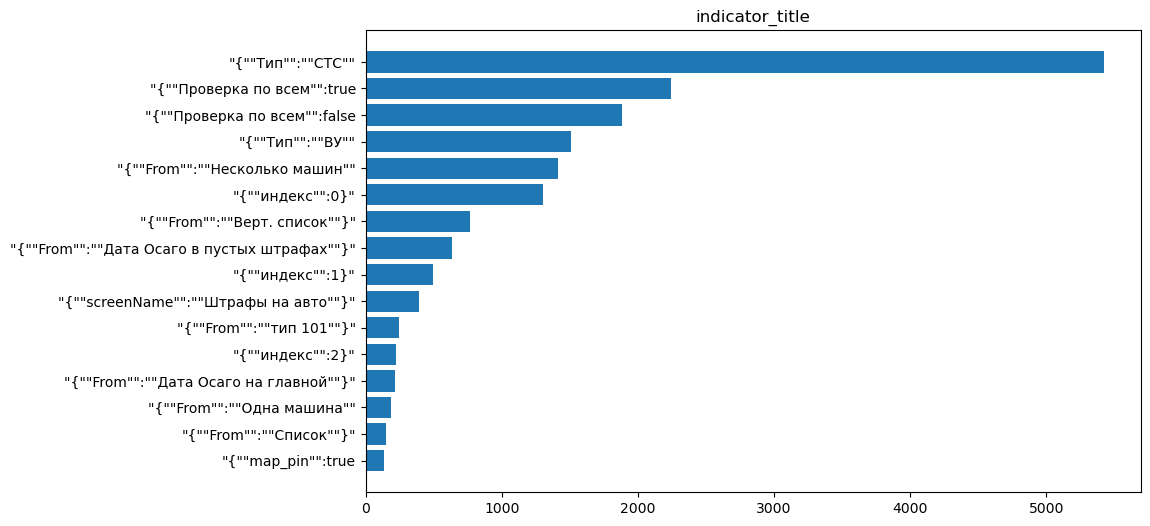

In [20]:
# Let's try to visualize top 10 most common event codes in the chunk
def plot_top( df, indicator_title, top = 10):
    event_codes = df[indicator_title].value_counts().reset_index()
    event_codes = event_codes.loc[:15]
    
    plt.figure(figsize = (10,6))
    plt.barh(event_codes[indicator_title], event_codes['count'])
    plt.gca().invert_yaxis()
    plt.title('indicator_title')
    plt.show()
plot_top(df_test, 'event_json', top = 15)

We can see that the most frequent value occurs only app. 630 times in the chunk with 30000 rows which is 2.1%. We can conclude that event codes are highly diverse and do not exhibit strong dominance by any single category.

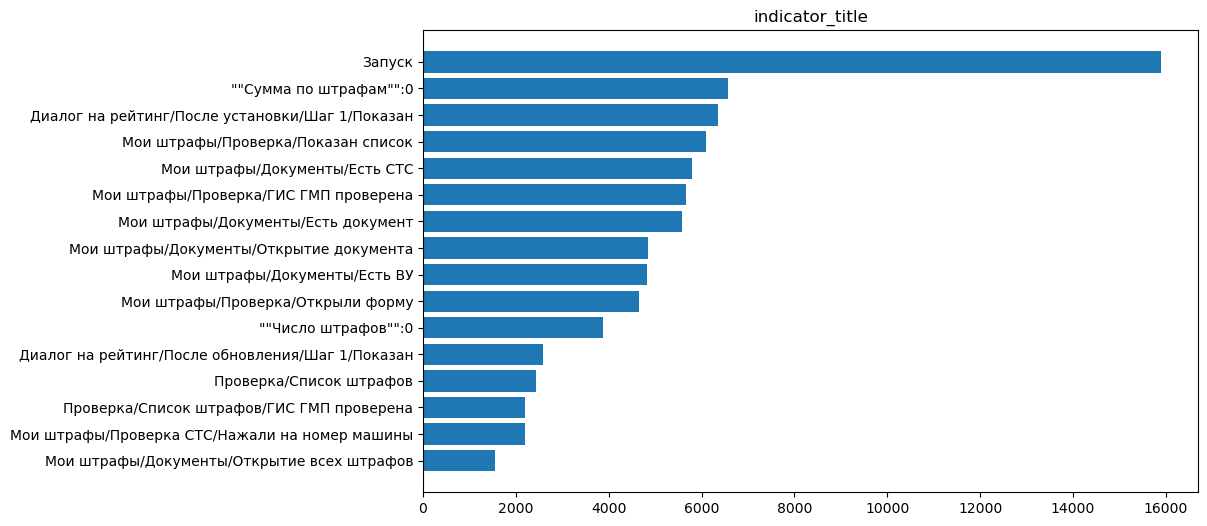

In [21]:
plot_top(df_test, 'event_name', top = 15)

"Запуск" is the most frequent category in the chunk

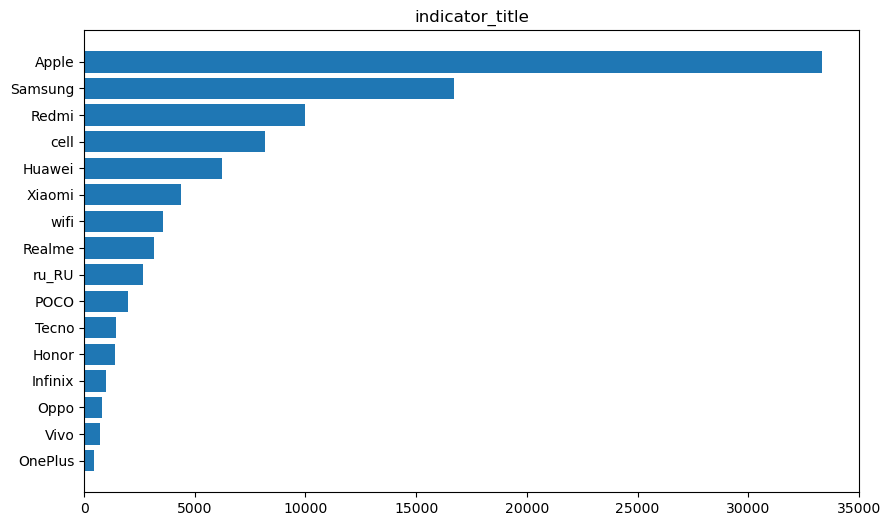

In [22]:
plot_top(df_test, 'device_manufacturer', top = 15)

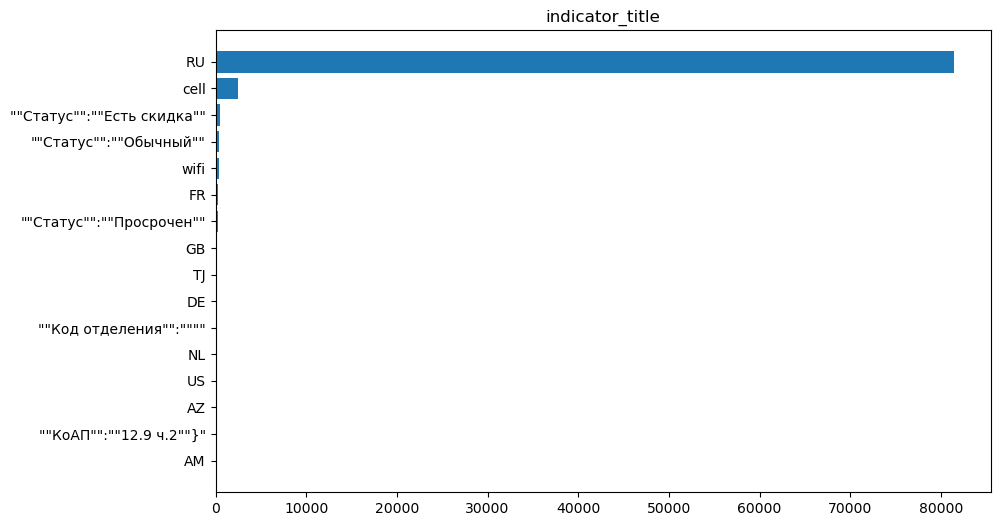

In [23]:
plot_top(df_test, 'country_iso_code', top = 15)

There are some errors in the provided data

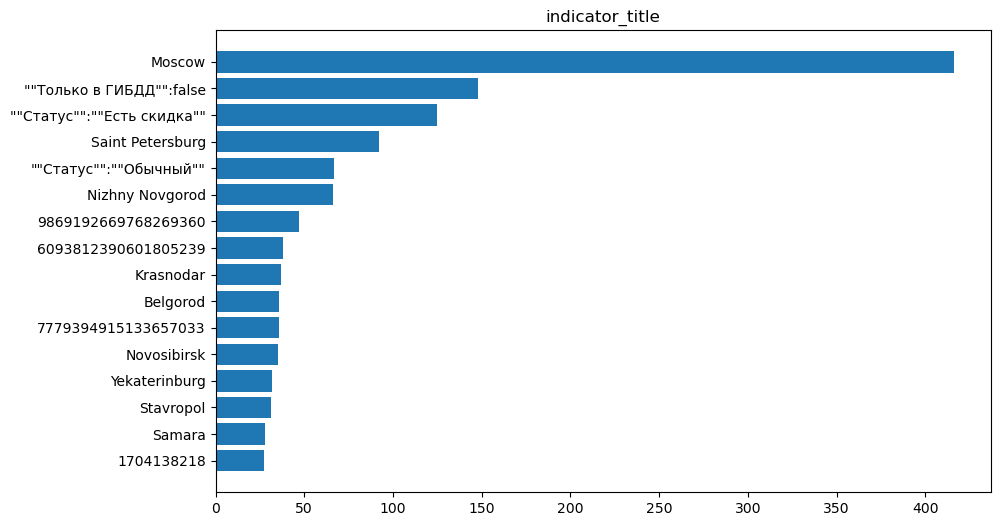

In [24]:
plot_top(df_test, 'city', top = 20)

Most users are in Moscow

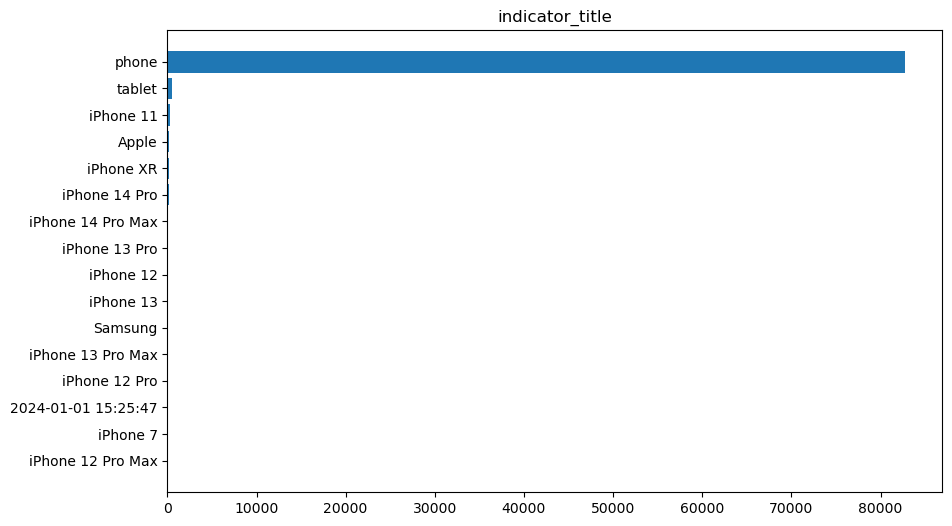

In [25]:
plot_top(df_test, 'device_type', top = 15)

Most of the launches are from a phone

We can try to play with the time of action

In [26]:
df_test['event_datetime'] = pd.to_datetime(df_test.event_datetime)

In [27]:
df_test['hour'] = df_test.event_datetime.dt.hour

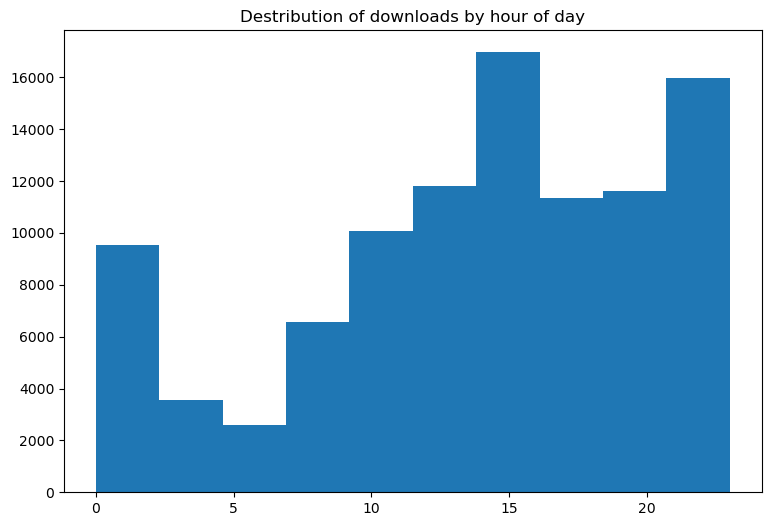

In [28]:
plt.figure(figsize = (9,6))
plt.title('Destribution of downloads by hour of day')
plt.hist(df_test.hour);

We can also calculate the average number of actions per one session and average duration of a session

In [29]:
session = df_test['session_id'].value_counts().reset_index()
session['col_numeric'] = pd.to_numeric(session['session_id'], errors='coerce')
session = session.dropna(subset=['col_numeric'])
print(f'The average number of actions per 1 session is {round(session["count"].mean(),2)}')

The average number of actions per 1 session is 12.39


Most likely, the target variable is event_name. We need to find something similar to Fine payment in the logs.   
Let's save all the unique values of this feature into a txt file and manually go through them

In [30]:
unique_events = df_test.event_name.unique()
with open('unique_events.txt', 'w', encoding='utf-8') as file:
    for item in unique_events:
        file.write(f"{item}\n")

## Let's read all the files

In [101]:
from pyspark.sql.types import (
    StructType, StructField, StringType
)

schema = StructType([
    StructField("event_datetime", StringType(), True),
    StructField("event_json", StringType(), True),
    StructField("event_name", StringType(), True),
    StructField("event_receive_datetime", StringType(), True),
    StructField("event_receive_timestamp", StringType(), True),
    StructField("event_timestamp", StringType(), True),
    StructField("session_id", StringType(), True),
    StructField("installation_id", StringType(), True),
    StructField("appmetrica_device_id", StringType(), True),
    StructField("city", StringType(), True),
    StructField("connection_type", StringType(), True),
    StructField("country_iso_code", StringType(), True),
    StructField("device_ipv6", StringType(), True),
    StructField("device_locale", StringType(), True),
    StructField("device_manufacturer", StringType(), True),
    StructField("device_model", StringType(), True),
    StructField("device_type", StringType(), True),
    StructField("google_aid", StringType(), True),
    StructField("ios_ifa", StringType(), True),
    StructField("ios_ifv", StringType(), True),
    StructField("mcc", StringType(), True),
    StructField("mnc", StringType(), True),
    StructField("operator_name", StringType(), True),
    StructField("original_device_model", StringType(), True),
    StructField("os_name", StringType(), True),
    StructField("os_version", StringType(), True),
    StructField("profile_id", StringType(), True),
    StructField("windows_aid", StringType(), True),
    StructField("app_build_number", StringType(), True),
    StructField("app_package_name", StringType(), True),
    StructField("app_version_name", StringType(), True),
    StructField("application_id", StringType(), True)
])

In [102]:
df_all = spark.read \
            .option("header", "true") \
            .schema(schema) \
            .csv(dir_path + "/*.csv")
            

In [103]:
df_all.columns

['event_datetime',
 'event_json',
 'event_name',
 'event_receive_datetime',
 'event_receive_timestamp',
 'event_timestamp',
 'session_id',
 'installation_id',
 'appmetrica_device_id',
 'city',
 'connection_type',
 'country_iso_code',
 'device_ipv6',
 'device_locale',
 'device_manufacturer',
 'device_model',
 'device_type',
 'google_aid',
 'ios_ifa',
 'ios_ifv',
 'mcc',
 'mnc',
 'operator_name',
 'original_device_model',
 'os_name',
 'os_version',
 'profile_id',
 'windows_aid',
 'app_build_number',
 'app_package_name',
 'app_version_name',
 'application_id']

In [104]:
df_all.printSchema()

root
 |-- event_datetime: string (nullable = true)
 |-- event_json: string (nullable = true)
 |-- event_name: string (nullable = true)
 |-- event_receive_datetime: string (nullable = true)
 |-- event_receive_timestamp: string (nullable = true)
 |-- event_timestamp: string (nullable = true)
 |-- session_id: string (nullable = true)
 |-- installation_id: string (nullable = true)
 |-- appmetrica_device_id: string (nullable = true)
 |-- city: string (nullable = true)
 |-- connection_type: string (nullable = true)
 |-- country_iso_code: string (nullable = true)
 |-- device_ipv6: string (nullable = true)
 |-- device_locale: string (nullable = true)
 |-- device_manufacturer: string (nullable = true)
 |-- device_model: string (nullable = true)
 |-- device_type: string (nullable = true)
 |-- google_aid: string (nullable = true)
 |-- ios_ifa: string (nullable = true)
 |-- ios_ifv: string (nullable = true)
 |-- mcc: string (nullable = true)
 |-- mnc: string (nullable = true)
 |-- operator_name: s